In [76]:
import numpy as np
from filterpy.kalman import ExtendedKalmanFilter
# import jax
# import jax.numpy as jnp
import joblib
from matplotlib import pyplot as plt

In [77]:
# light_cureve_dict = joblib.load("subset_q1.joblib")

# #vals is flux
# #time (day), flux, possible error recorded by error
# t, vals, err = light_cureve_dict[5097470][:3]
# #100 stars

# #set nan_values to be the average of its neighbors
# nan_indices = np.argwhere(np.isnan(vals))
# for nan_index in nan_indices:
#     vals[nan_index] = (vals[nan_index - 1] + vals[nan_index + 1]) / 2

# plt.plot(t, vals)

**FIVE STARS**

In [78]:
def h(theta):
    #the average flux (this should be zero bc I standardized the data)
    y0 = 0
    #transit depth
    # 0.9
    # t_depth = 5
    t_depth = 0.9

    #steepness of the curve
    # sigma = 1.5
    sigma = 0.9


    thet = theta[0]
    result = y0 - t_depth*np.exp(-(1-np.cos(thet))/sigma)
    return np.array([float(result)])


def h_der(theta):
    #THESE NEED TO MATCH WHAT'S ABOVE
    #transit depth
    t_depth = 0.9
    #steepness of the curve
    sigma = 0.9
    thet = theta[0]
    result = (-t_depth*np.sin(thet)/sigma) * np.exp(-(1-np.cos(thet))/sigma)
    return np.array([[float(result), 0.0]])

In [79]:
light_curve_dict = joblib.load("5_stars.joblib")

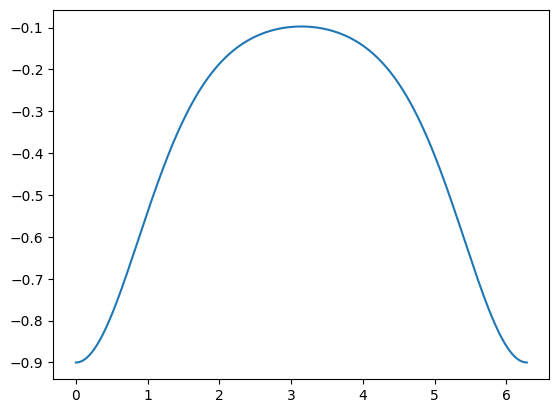

In [80]:
# jobids = light_curve_dict.keys()
# for id in jobids:
#     vals = np.asarray(light_curve_dict[id]['flux'], dtype=float)
#     t = np.asarray(light_curve_dict[id]['time'], dtype=float)

#     #set nan_values to be the average of its neighbors
#     nan_indices = np.argwhere(np.isnan(vals))
#     for nan_index in nan_indices:
#         vals[nan_index] = (vals[nan_index - 1] + vals[nan_index + 1]) / 2

#     valid_ind = np.where(np.isfinite(vals))[0]
#     vals = vals[valid_ind]
#     t = t[valid_ind]

#     # clipped = np.clip(vals, 402000, 406000)
#     mean_v = np.mean(vals)
#     std_v = np.std(vals)
#     new_vals = (vals - mean_v) / std_v
#     plt.plot(t, vals)
#     plt.show()

#     plt.plot(t, new_vals)
#     plt.show()
#     break

thetas_test = np.linspace(0, 2*np.pi, 500)
plt.plot(thetas_test, [h([th, 0])[0] for th in thetas_test])
plt.show()

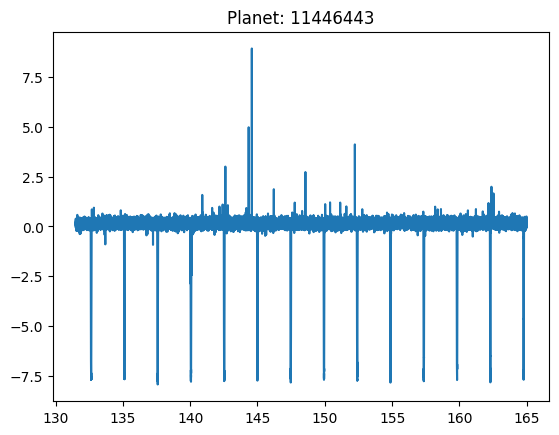

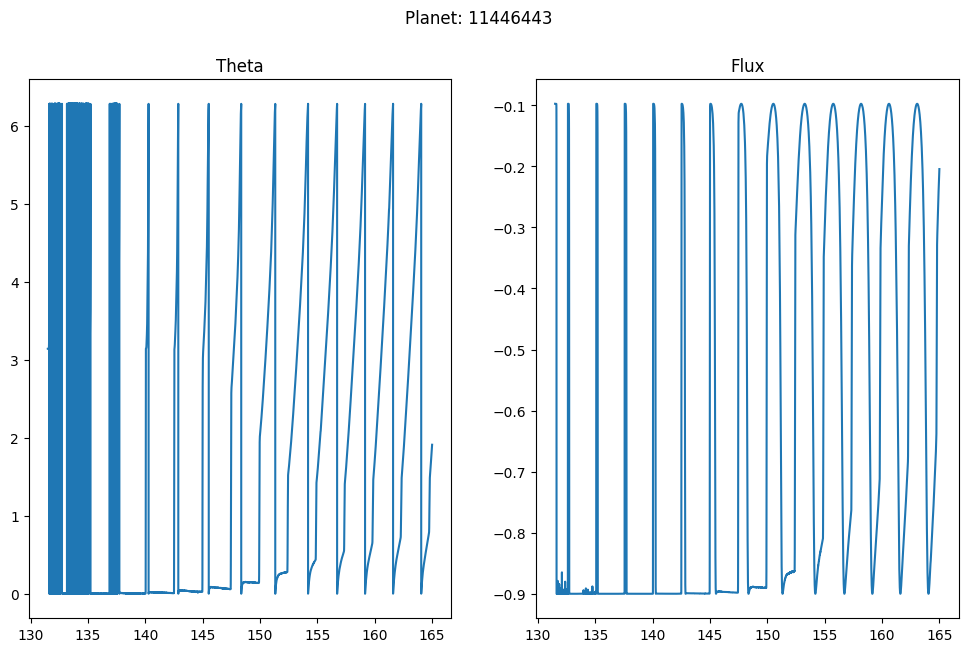

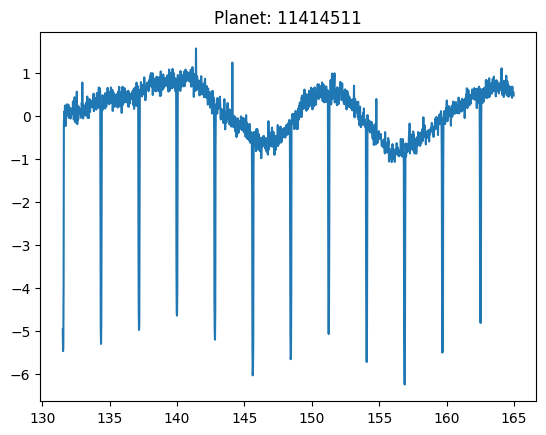

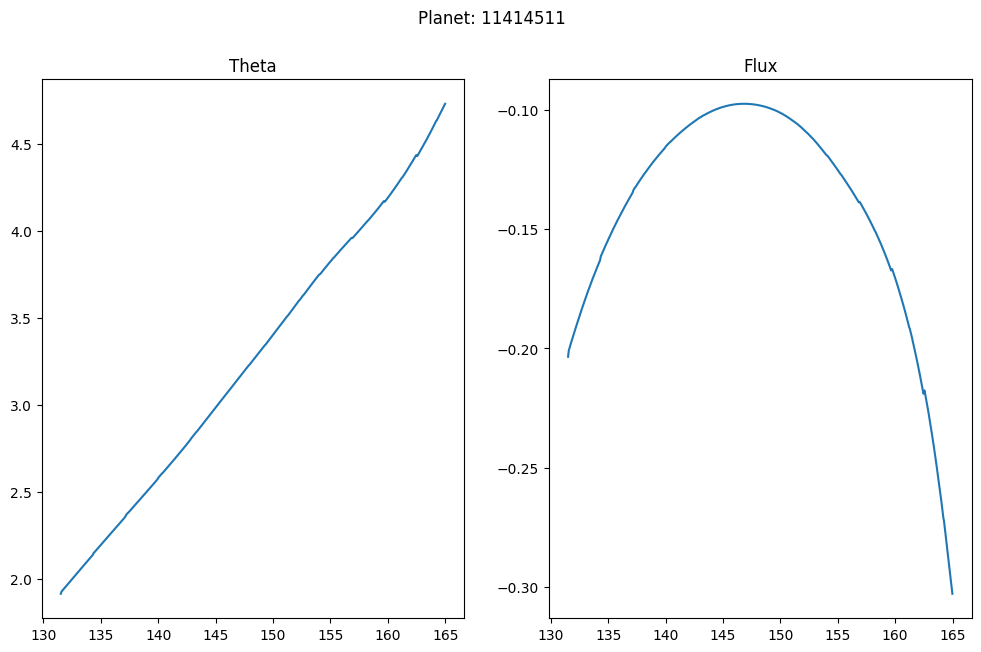

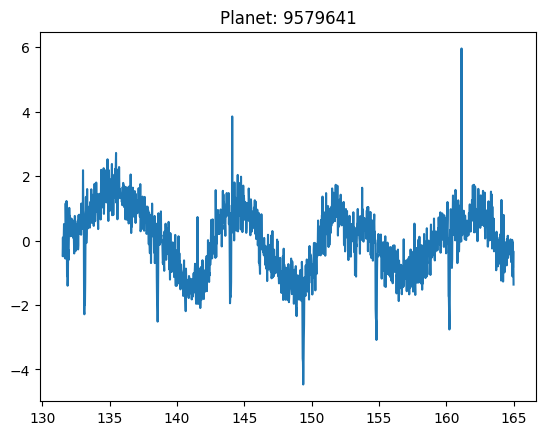

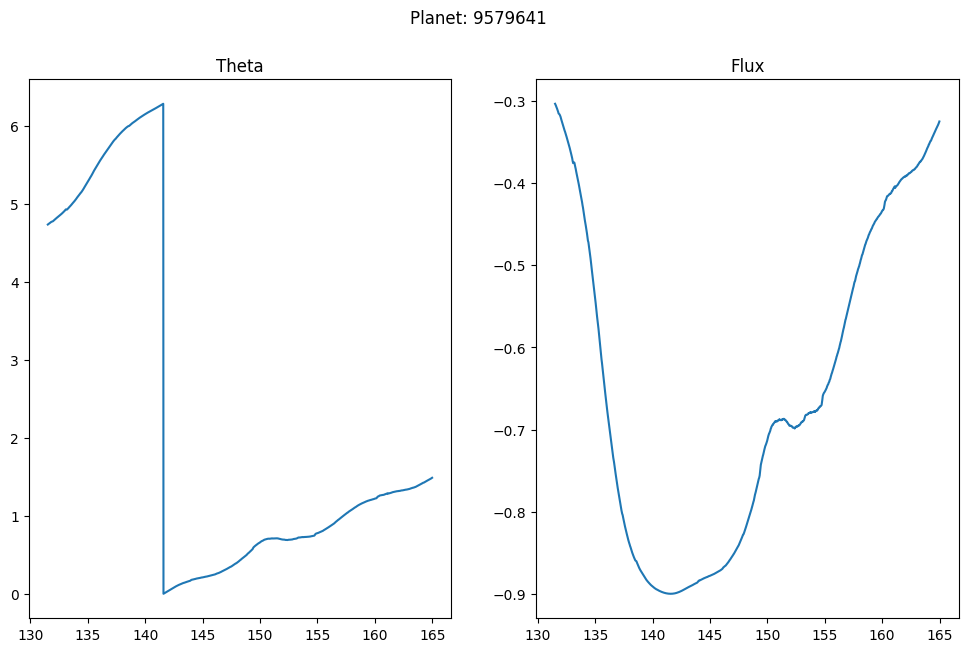

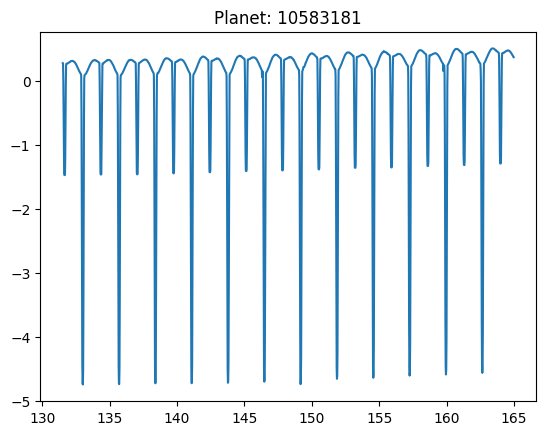

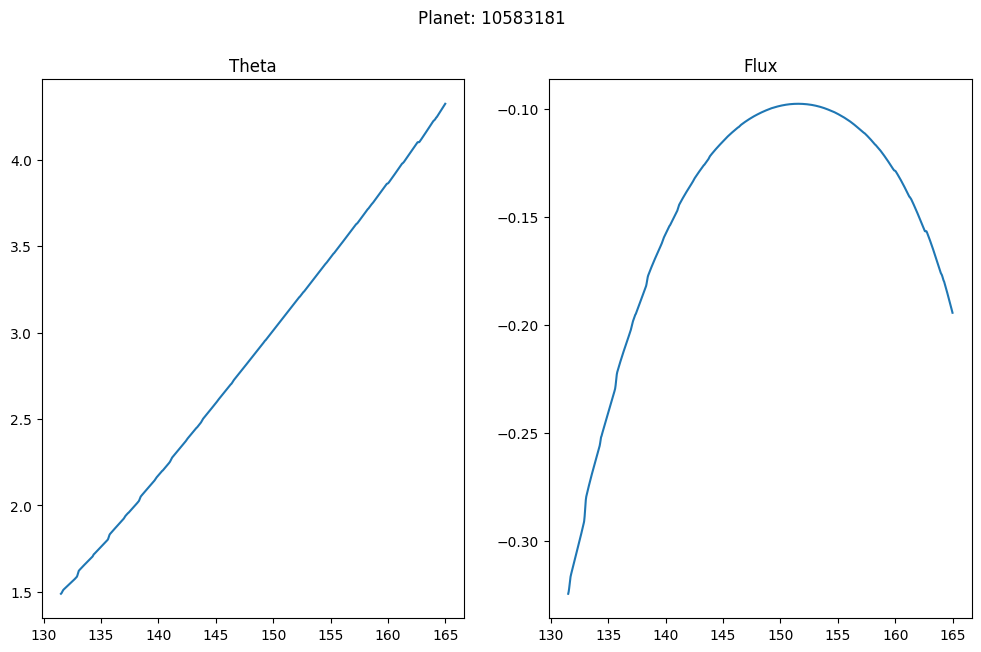

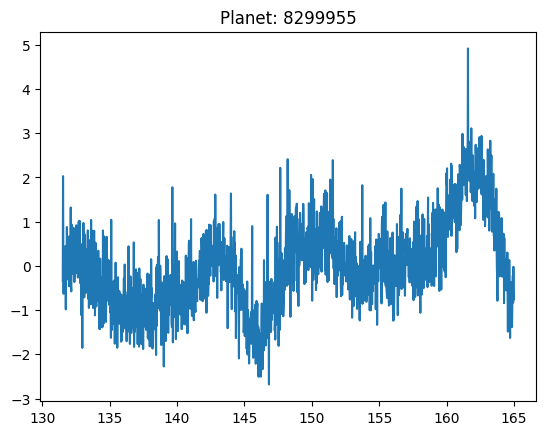

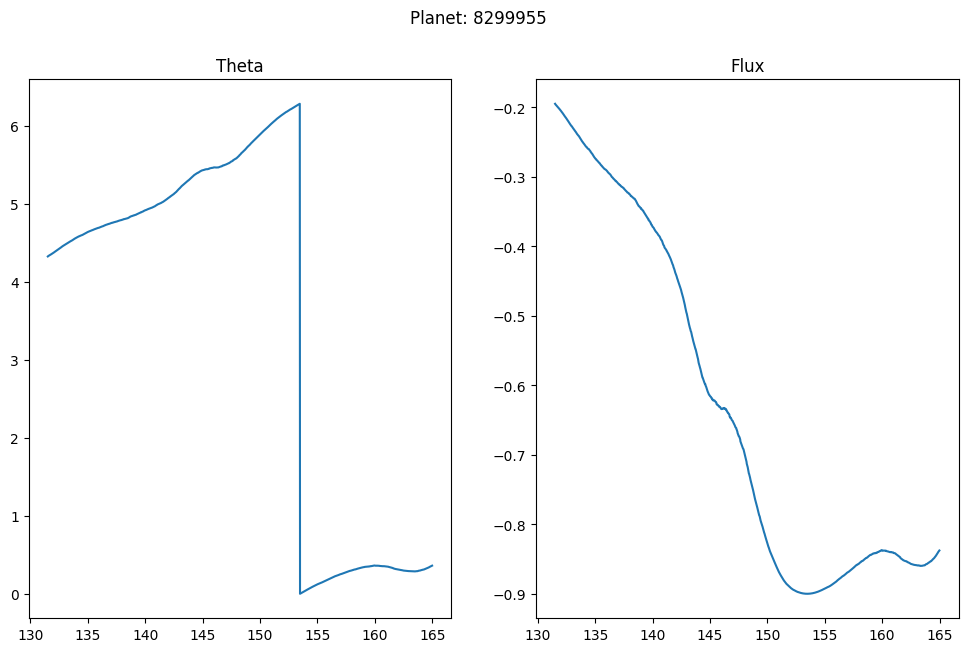

In [81]:
#theta
G = 6.67e-11
dt = 0.01

dim_x = 2
dim_z = 1

ekf = ExtendedKalmanFilter(dim_x, dim_z)

#initial state, x = [theta, angular velocity]
#I got my angular velocity from my first google search
ekf.x = np.array([[np.pi], [7.26e-5]])
ekf.P = np.eye(2)

#Linear State
ekf.F = np.array([[1.0, dt], [0.0, 1.0]])

#Noise
ekf.Q = np.eye(2)*1e-10
# ekf.R = np.array([[20/10**6]])
ekf.R = np.array([[1.0]])
#ekf.R = np.array([[x*20/10**6]])

jobids = light_curve_dict.keys()
#vals is flux
for id in jobids:
    vals = np.asarray(light_curve_dict[id]['flux'], dtype=float)
    t = np.asarray(light_curve_dict[id]['time'], dtype=float)

    #set nan_values to be the average of its neighbors
    nan_indices = np.argwhere(np.isnan(vals))
    for nan_index in nan_indices:
        vals[nan_index] = (vals[nan_index - 1] + vals[nan_index + 1]) / 2

    valid_ind = np.where(np.isfinite(vals))[0]
    vals = vals[valid_ind]
    t = t[valid_ind]

    mean_v = np.mean(vals)
    std_v = np.std(vals)
    new_vals = (vals - mean_v) / std_v

    plt.plot(t, new_vals)
    plt.title(f'Planet: {id}')
    plt.show()

    thetas = []
    angular_vel = []
    for i, flux in enumerate(new_vals):
        ekf.predict()
        ekf.update(z=np.array([[flux]]), HJacobian=h_der, Hx=h)
        ekf.x[0][0] = ekf.x[0][0] % (2*np.pi)
        th, av = ekf.x.ravel()
        thetas.append(th)
        angular_vel.append(av)

    plt.figure(figsize=(12, 7))
    plt.subplot(121)
    #plot the observed measurements and then our thetas turned into brightness via H
    # plt.plot(t[::20], thetas[::20])
    plt.plot(t, thetas)
    plt.ticklabel_format(style='plain', axis='both', useOffset=False)
    plt.title(f"Theta")

    plt.subplot(122)
    #plot the observed measurements and then our thetas turned into brightness via H
    plt.plot(t, [h([th, 0]) for th in thetas])
    plt.ticklabel_format(style='plain', axis='both', useOffset=False)
    plt.title(f"Flux")

    plt.suptitle(f"Planet: {id}")
    plt.show()

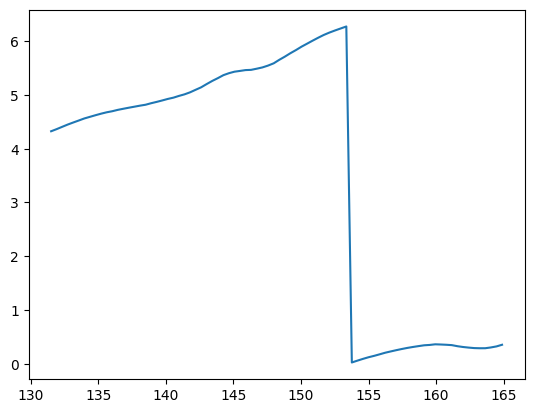

In [82]:
#plot the observed measurements and then our thetas turned into brightness via H
plt.plot(t[::20], thetas[::20])
plt.ticklabel_format(style='plain', axis='both', useOffset=False)

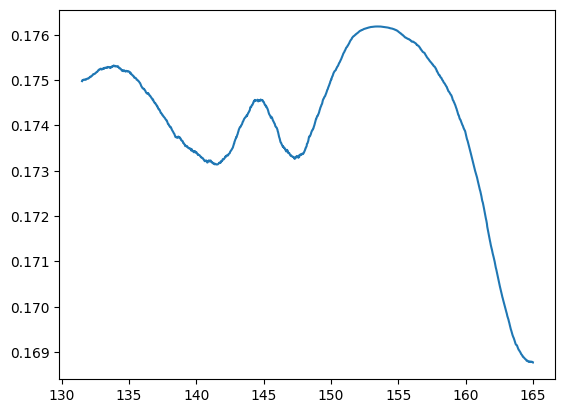

In [83]:
#plot the observed measurements and then our thetas turned into brightness via H
plt.plot(t, angular_vel)
plt.ticklabel_format(style='plain', axis='both', useOffset=False)